# Analizando el Cálculo de la FFT paso a paso en ESP-DSP

Este notebook sirve como apoyo visual interactivo para comprender cómo se calcula la Transformada Rápida de Fourier (FFT) en el microcontrolador ESP32 usando la biblioteca oficial **ESP-DSP**.

Tomaremos como caso de estudio el archivo de C `ejemplos_C/frequency_analysis/main/frequency_analysis_main.c`.

In [1]:
from scipy import fft
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Simulemos la importación de nuestro archivo .h en C
# Vamos a leer el archivo wav equivalente a utilizar #include "chord-C.h"
fs, senial_pura = wavfile.read('chord-C.wav')
if len(senial_pura.shape) > 1:
    senial_pura = senial_pura[:,0]
senial_pura = senial_pura.astype(float)

## 1. El Tamaño de la Muestra (Potencias de 2)

En el código en C vemos estas macros:

```c
#define POW2            (BITS_TO_REPRESENT(N_CHORD) -1 )
#define N_POW2          (1 << (POW2)) // Power of two nearest to number of samples
```

La función de la biblioteca ESP-DSP que implementa la transformada en hardware se basa en el algoritmo Radix-2, el cual requiere obligatoriamente que la longitud de los arreglos numéricos a procesar sea una potencia exacta de 2. Por lo tanto recortamos la señal para que su longitud sea la potencia de 2 más cecana a longitud original.

In [2]:
N_CHORD = len(senial_pura)
POW2 = int(np.floor(np.log2(N_CHORD)))
N_POW2 = 1 << POW2

print(f"Muestras originales: {N_CHORD}")
print(f"Muestras N_POW2 a utilizar para la FFT: {N_POW2}")

senial = senial_pura[:N_POW2]

Muestras originales: 16000
Muestras N_POW2 a utilizar para la FFT: 8192


## 2. Conversión de Datos y Tensión Simulada (`TO_MV`)

Se realiza una normalización de los datos digitales analógicos de 16bits, llevándolos a valores de tensión (mV) en base a la alimentación (`VDD`):

```c
#define MAX_ADC         32768                           // 16 bit audio signals
#define VDD             3300                            // VDD is 3.3V, 3300mV
#define TO_MV(x)        (float)(x)*VDD/MAX_ADC          // Data convertion to mV

/* ... */

/* Signal in mV */
for(uint16_t i=0; i<N_POW2; i++){
    signal[i] = TO_MV(chord[i]);  
}
```

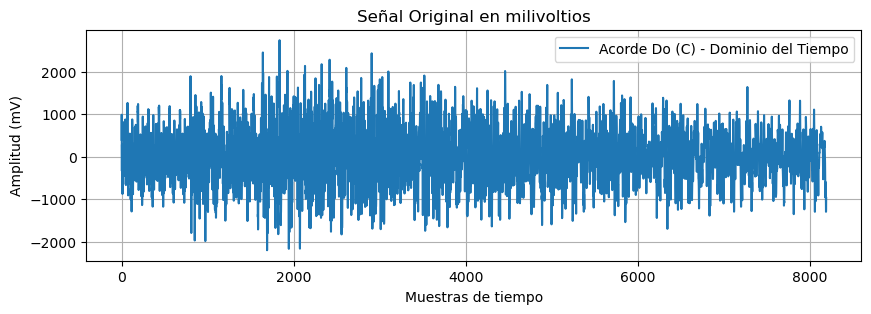

In [3]:
MAX_ADC = 32768.0
VDD = 3300.0
signal_mv = senial * VDD / MAX_ADC

plt.figure(figsize=(10,3))
plt.plot(signal_mv, label='Acorde Do (C) - Dominio del Tiempo')
plt.title("Señal Original en milivoltios")
plt.xlabel("Muestras de tiempo")
plt.ylabel("Amplitud (mV)")
plt.legend()
plt.grid()
plt.show()

## 3. La Preparación del Arreglo Complejo (`dsps_mul_f32`)

Antes de aplicar el algoritmo de FFT debemos preparar el vector de señal, expresándolo en valores complejos: `[Real(0), Imag(0), Real(1), Imag(1)...]`. También aplicaremos una ventana de Hann a la señal, para evitar *fuga espectral* al calcular su espectro. 

```c
// Input signal
__attribute__((aligned(16))) float signal[N_POW2];
// Window coefficients
__attribute__((aligned(16))) float wind[N_POW2];
// working complex array
__attribute__((aligned(16))) float fft[N_POW2*2];

/*...*/

/* Generate Hann window */
dsps_wind_hann_f32(wind, N_CHORD);

/*...*/

// Multiply input array with window and store as real part
dsps_mul_f32(signal, wind, fft, N_CHORD, 1, 1, 2);
// Clear imaginary part of the complex signal
dsps_mulc_f32(&fft[1], &fft[1], N_CHORD, 0, 2, 2);
```

- Se aplica una ventana de Hann para reducir derrames espectrales en los bordes de la señal. Se guarda el resultado con un salto o `step = 2`. Esto guarda los valores *reales de la componente temporal* en las posiciones **pares** del array `fft`.<br>
- Se utiliza `dsps_mulc_f32`, para limpiar todas las celdas **impares** dejándolas en $0$.<br>

**¿Por qué usamr `__attribute__((aligned(16)))`?** <br> 
La biblioteca ESP-DSP implementa muchas de sus funciones usando instrucciones altamente optimizadas. En los procesadores con instrucciones tipo SIMD (como el **Xtensa**), se procesan múltiples datos en paralelo. Para habilitar estas operaciones de alta velocidad, las direcciones físicas en memoria RAM de los arreglos deben arrancar respetando un contorno de **16 bytes**. Por esta razón usamos el prefijo para solicitarle al compilador dicha posición exacta de reserva. Si se usa memoria sin alinear se puede perder drásticamente el beneficio computacional.

> NOTA: ver la documentación de las funciones [dsps_mul_f32()](https://docs.espressif.com/projects/esp-dsp/en/latest/esp32/esp-dsp-apis.html#basic-math) y  [dsps_mulc_f32()](https://docs.espressif.com/projects/esp-dsp/en/latest/esp32/esp-dsp-apis.html#basic-math).


Primeros 8 valores del array de complejos (R_0, I_0, R_1, I_1 ...):
[ 0.          0.          0.00014581  0.          0.00020895  0.
 -0.00044122  0.        ]


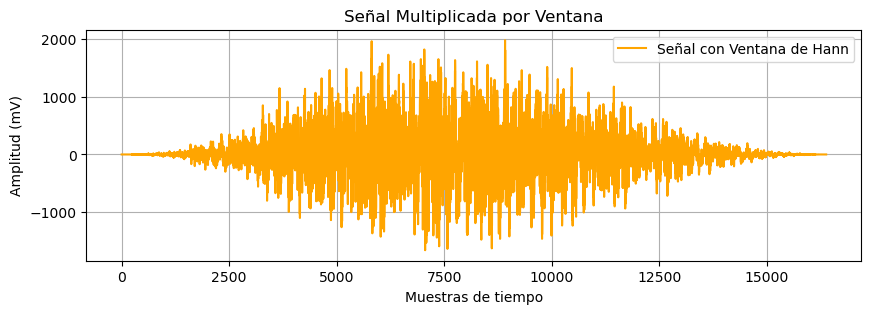

In [4]:
from scipy.signal.windows import hann

# Se Genera Ventana Hann 
window = hann(N_POW2, sym=False) 

# Configuramos el array lineal de FFT para alojar los N_POW2 complejos (N_POW2 * 2 reales empaquetados)
fft_buffer = np.zeros(N_POW2 * 2)

# dsps_mul_f32() - En las celdas pares ubicamos los valores reales del producto de la señal por la ventana de Hann.
fft_buffer[0::2] = signal_mv * window 

# dsps_mulc_f32() - En las celdas impares completamos con ceros
fft_buffer[1::2] = 0.0          

print("Primeros 8 valores del array de complejos (R_0, I_0, R_1, I_1 ...):")
print(fft_buffer[:8])

plt.figure(figsize=(10,3))
plt.plot(fft_buffer, label='Señal con Ventana de Hann', color='orange')
plt.title("Señal Multiplicada por Ventana")
plt.xlabel("Muestras de tiempo")
plt.ylabel("Amplitud (mV)")
plt.legend()
plt.grid()
plt.show()

## 4. Cálculo de FFT: Ejecución, Operación Radix y Desentrelazamiento

```c
// Calculate FFT  
dsps_fft2r_fc32(fft, N_POW2);
// Bit reverse
dsps_bit_rev_fc32(fft, N_POW2);
// Convert one complex vector to two complex vectors
dsps_cplx2reC_fc32(fft, N_POW2);
```

**1-** La función `dsps_fft2r_fc32` calcula el espectro en tiempo real reescribiendo la misma variable. Un rasgo muy conocido del algoritmo utilizado internamente es que deja las frecuencias codificadas en un orden pseudo-aleatorio (orden 'bit-reversed'). Eso significa que el bin k de la FFT queda almacenado en la posicion bit_reverse(k), no en la posicion k. Se necesita dsps_bit_rev_fc32 para reordenarlos correctamente.<br>
**2-** Se hace necesario llamar seguidamente a **Bit-Reversal** (`dsps_bit_rev_fc32`) para reordenar las frecuencias en formato ascendente convencional.<br>
**3-** La senial de entrada es Real (Im=0), por lo tanto su espectro es simetrico: ``X[N-k] = conj(X[k])``. En lugar de almacenar las N frecuencias del espectro completo, esta funcion combina el espectro positivo y negativo: dado que ``Z_bit_rev = FFT de (senial + j*0)``, la parte positiva se puede extraer con: ``X_pos[k] = ( Z[k] + conj(Z[N/2 - k]) ) / 2     k = 0 ... N/2 - 1``. El resultado son N/2 bins complejos que representan el espectro de 0 Hz a fs/2 Hz.

> NOTA: ver la documentación de las funciones [dsps_fft2r_fc32()](https://docs.espressif.com/projects/esp-dsp/en/latest/esp32/esp-dsp-apis.html#fft),  [dsps_bit_rev_fc32()](https://docs.espressif.com/projects/esp-dsp/en/latest/esp32/esp-dsp-apis.html#fft) y [dsps_cplx2reC_fc32()](https://docs.espressif.com/projects/esp-dsp/en/latest/esp32/esp-dsp-apis.html#fft).

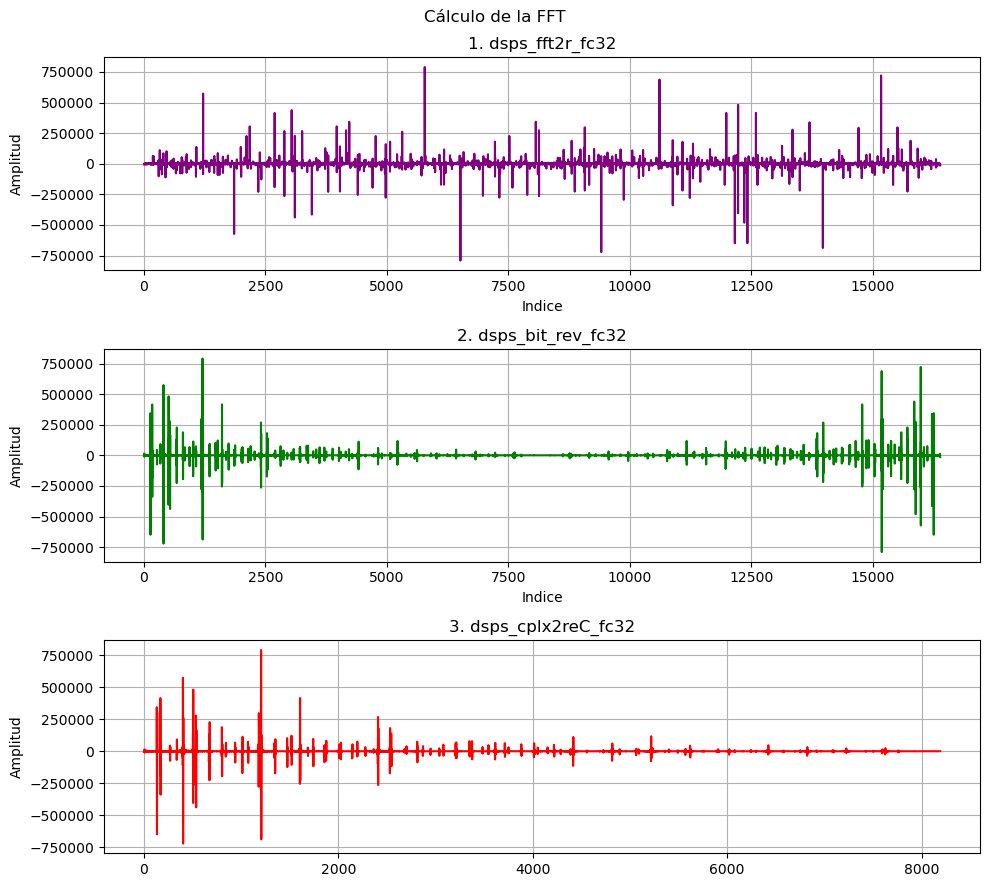

In [5]:
# Representamos el buffer como un vector de N_POW2 numeros complejos
z_in = fft_buffer[0::2] + 1j * fft_buffer[1::2]

# 1: dsps_fft2r_fc32(fft, N_POW2)
# Algoritmo FFT Radix-2 in-place.
#
# Simulacion: aplicamos np.fft.fft y luego la permutacion bit-reversal.
bits = int(np.log2(N_POW2))
br_idx = np.array([int(bin(i)[2:].zfill(bits)[::-1], 2) for i in range(N_POW2)])
Z_full  = np.fft.fft(z_in)     # FFT completa en orden natural
Z_fft2r = Z_full[br_idx]       # reordenar a bit-reversed (estado real del buffer)
# Buffer intercalado [Re0,Im0,Re1,Im1,...] tal como lo deja dsps_fft2r_fc32
buf_fft2r = np.empty(N_POW2 * 2, dtype=np.float32)
buf_fft2r[0::2] = Z_fft2r.real.astype(np.float32)
buf_fft2r[1::2] = Z_fft2r.imag.astype(np.float32)

# 2: dsps_bit_rev_fc32(fft, N_POW2)
# Recorre el buffer y permuta los bins de orden bit-reversed al orden de
# frecuencia natural: bin 0 = DC (0 Hz), bin k = k * fs/N_POW2.
#
# Simulacion: aplicamos br_idx sobre Z_fft2r para volver a Z_full.
Z_bit_rev = Z_fft2r[br_idx]    # deshacer el bit-reversal = orden natural
buf_bit_rev = np.empty(N_POW2 * 2, dtype=np.float32)
buf_bit_rev[0::2] = Z_bit_rev.real.astype(np.float32)
buf_bit_rev[1::2] = Z_bit_rev.imag.astype(np.float32)

# 3: dsps_cplx2reC_fc32(fft, N_POW2)
# Esta funcion combina el espectro positivo y negativo.
# El resultado son N/2 bins complejos que representan el espectro de 0 Hz a fs/2 Hz.

N_half = N_POW2 // 2
X_pos = np.array([
    0.5 * (Z_bit_rev[k] + np.conj(Z_bit_rev[(N_POW2 - k) % N_POW2]))
    for k in range(N_half)
], dtype=np.complex64)

# Buffer de salida: N_half pares (Re, Im) intercalados = N_POW2/2 * 2 floats
buf_cplx2reC = np.empty(N_half * 2, dtype=np.float32)
buf_cplx2reC[0::2] = X_pos.real.astype(np.float32)
buf_cplx2reC[1::2] = X_pos.imag.astype(np.float32)

# Graficación
fig, axes = plt.subplots(3, 1, figsize=(10, 9))
fig.suptitle("Cálculo de la FFT")

# -- dsps_fft2r_fc32 --
axes[0].plot(buf_fft2r, color="purple")
axes[0].set_title("1. dsps_fft2r_fc32")
axes[0].set_xlabel("Indice")
axes[0].set_ylabel("Amplitud")
axes[0].grid(True)

# -- dsps_bit_rev_fc32 --
axes[1].plot(buf_bit_rev, color="green")
axes[1].set_title("2. dsps_bit_rev_fc32")
axes[1].set_xlabel("Indice")
axes[1].set_ylabel("Amplitud")
axes[1].grid(True)

# -- dsps_cplx2reC_fc32 --
axes[2].plot(buf_cplx2reC, color="red")
axes[2].set_title("3. dsps_cplx2reC_fc32")
axes[2].set_ylabel("Amplitud")
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Dejamos X_pos disponible para el Paso 5 (calculo de magnitud)
espectro_completo = X_pos


## 5. El Cálculo Numérico de la Magnitud Absoluta y Paso a Potencia

```c
// Magnitud:
for (int j = 0; j < N_POW2; j++){
    fft[j] = 2*(sqrt(fft[j*2+0]*fft[j*2+0] + fft[j*2+1]*fft[j*2+1])) / (N_POW2/2);
}
fft[0] = fft[0] / 2;

// Potencia:
for (int j = 0; j < N_POW2/2; j++){
    fft[j] = fft[j]*fft[j];
}
```
En C, para calcular el Módulo a partir de los pares de números complejos, tomamos el par de elementos colindantes del array calculamos: $M(j) = 2 \cdot \frac{\sqrt{Re^2 + Im^2}}{N/2}$. 

Por consiguiente para obtener el espectro en potencia (`mW`) bastará con elevar al cuadrado cada elemento $P(j) = M(j)^2$.

In [6]:
# Replicando en Python:
modulo = np.abs(espectro_completo)                 # Cálculo del módulo

magnitud = 2 * modulo / (N_POW2 / 2.0)             # Escalamiento 
magnitud[0] = magnitud[0] / 2.0 

# Computar a mW (V^2): 
potencia = magnitud ** 2


## 6. Salida Espectral Serie (dsps_view)

La función `dsps_view` emula una gráfica por consola (`ASCII art`). 

```c
dsps_view(fft, N_POW2/2, PLOT_WIDTH, PLOT_HEIGHT, 0, fft_max, '*');
```

> NOTA: ver la documentación de las funciones [dsps_view()](https://docs.espressif.com/projects/esp-dsp/en/latest/esp32/esp-dsp-apis.html#support)

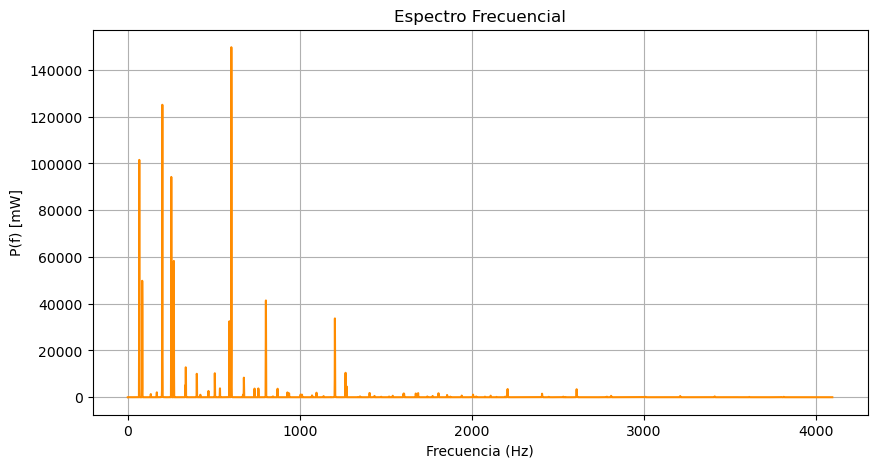

In [7]:
plt.figure(figsize=(10,5))
plt.plot(potencia, color='darkorange')
plt.title("Espectro Frecuencial")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("P(f) [mW]")
plt.grid()
plt.show()